In [10]:
# Cell 1 — Environment Setup
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data_loader import DATA_PROC, NUM_CLASSES, EMOTION_LABELS, CNN_WEIGHT, PHYSIO_WEIGHT
from preprocess  import load_preprocessed_as_dataset, BATCH_SIZE
from model       import build_emotion_cnn, compile_model, get_callbacks, MODEL_PATH

OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
print(f'TensorFlow : {tf.__version__}')

print(f'\nThis trains the CNN Branch ({CNN_WEIGHT*100:.0f}% fusion weight)')
print(f'   Physio Branch ({PHYSIO_WEIGHT*100:.0f}%) uses MediaPipe (no training)')

TensorFlow : 2.15.0

This trains the CNN Branch (20% fusion weight)
   Physio Branch (80%) uses MediaPipe (no training)


In [11]:
# Cell 2 — GPU Verification (CRITICAL)
print('=' * 55)
print('  GPU STATUS CHECK')
print('=' * 55)
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print(f'CPU(s) : {len(cpus)}')
print(f'GPU(s) : {len(gpus)}')
if gpus:
    for g in gpus:
        print(f'{g.name}')
    # Enable memory growth
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print('   Memory growth enabled (prevents OOM)')
else:
    print('No GPU — training on CPU')
print()
print(f'Built with CUDA: {tf.test.is_built_with_cuda()}')
# Quick GPU test
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    x = tf.random.uniform((100, 48, 48, 1))
    _ = tf.reduce_sum(x)
print('TF compute test passed')

  GPU STATUS CHECK
CPU(s) : 1
GPU(s) : 1
/physical_device:GPU:0
   Memory growth enabled (prevents OOM)

Built with CUDA: True
TF compute test passed


In [12]:
# Cell 3 — Load preprocessed data
print('Loading train + val datasets...')
train_ds = load_preprocessed_as_dataset('train', augment=True,  batch_size=BATCH_SIZE)
val_ds   = load_preprocessed_as_dataset('val',   augment=False, batch_size=BATCH_SIZE)
n_train  = len(np.load(DATA_PROC / 'train_images_proc.npy'))
n_val    = len(np.load(DATA_PROC / 'val_images_proc.npy'))
print(f'Train: {n_train} samples  |  Val: {n_val} samples')
print(f'Batch size: {BATCH_SIZE}  →  {n_train//BATCH_SIZE} steps/epoch')

Loading train + val datasets...
Loaded preprocessed [train]: images=(25838, 48, 48, 1)
Loaded preprocessed [val]: images=(2871, 48, 48, 1)
Train: 25838 samples  |  Val: 2871 samples
Batch size: 64  →  403 steps/epoch


In [13]:
train_ds = train_ds.repeat()
val_ds   = val_ds.repeat()

In [14]:
# Cell 4 — Build CNN branch model
model = build_emotion_cnn()
model = compile_model(model, learning_rate=1e-3)
model.summary()
print(f'\nTotal params: {model.count_params():,}')

Model: "EmotionCNN_Branch"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 face_input (InputLayer)     [(None, 48, 48, 1)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 48, 48, 32)        320       
                                                                 
 bn1_1 (BatchNormalization)  (None, 48, 48, 32)        128       
                                                                 
 relu1_1 (Activation)        (None, 48, 48, 32)        0         
                                                                 
 conv1_2 (Conv2D)            (None, 48, 48, 32)        9248      
                                                                 
 bn1_2 (BatchNormalization)  (None, 48, 48, 32)        128       
                                                                 
 relu1_2 (Activation)        (None, 48, 48, 32)  

In [15]:
# Cell 5 — Visualize model architecture (saves PNG)
try:
    keras.utils.plot_model(
        model,
        to_file=str(OUTPUTS_DIR / 'cnn_architecture.png'),
        show_shapes=True, show_layer_names=True, dpi=80
    )
    print('Architecture saved → outputs/cnn_architecture.png')
except Exception as e:
    print(f'plot_model skipped: {e}')
    print('(Install graphviz + pydot if you want the diagram)')

plot_model skipped: name 'keras' is not defined
(Install graphviz + pydot if you want the diagram)


In [16]:
# Cell 6 — Setup callbacks
callbacks = get_callbacks(MODEL_PATH)
print('Callbacks configured:')
for cb in callbacks:
    print(f'  ✓ {cb.__class__.__name__}')
print(f'\nBest model → {MODEL_PATH}')

Callbacks configured:
  ✓ ModelCheckpoint
  ✓ ReduceLROnPlateau
  ✓ EarlyStopping

Best model → /home/ariba/Projects/stress_detection_project - Multi Factor/models/stress_emotion_model.keras


In [17]:
tf.get_logger().setLevel('ERROR')
print('Training CNN Branch...')
print(f'   Max epochs : 50  (EarlyStopping active)')
print(f'   Batch size : {BATCH_SIZE}')
print()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=n_train // BATCH_SIZE,
    validation_steps=n_val  // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)
print('\nTraining complete!')

Training CNN Branch...
   Max epochs : 50  (EarlyStopping active)
   Batch size : 64

Epoch 1/50
403/403 [==============================] - ETA: 0s - loss: 1.9693 - accuracy: 0.2350 - top3_acc: 0.5892
Epoch 1: val_accuracy improved from -inf to 0.17791, saving model to /home/ariba/Projects/stress_detection_project - Multi Factor/models/stress_emotion_model.keras
403/403 [==============================] - 9s 17ms/step - loss: 1.9693 - accuracy: 0.2350 - top3_acc: 0.5892 - val_loss: 1.9638 - val_accuracy: 0.1779 - val_top3_acc: 0.5508 - lr: 0.0010
Epoch 2/50
401/403 [============================>.] - ETA: 0s - loss: 1.6516 - accuracy: 0.3728 - top3_acc: 0.7172
Epoch 2: val_accuracy improved from 0.17791 to 0.35334, saving model to /home/ariba/Projects/stress_detection_project - Multi Factor/models/stress_emotion_model.keras
403/403 [==============================] - 9s 18ms/step - loss: 1.6511 - accuracy: 0.3727 - top3_acc: 0.7172 - val_loss: 1.8772 - val_accuracy: 0.3533 - val_top3_acc:

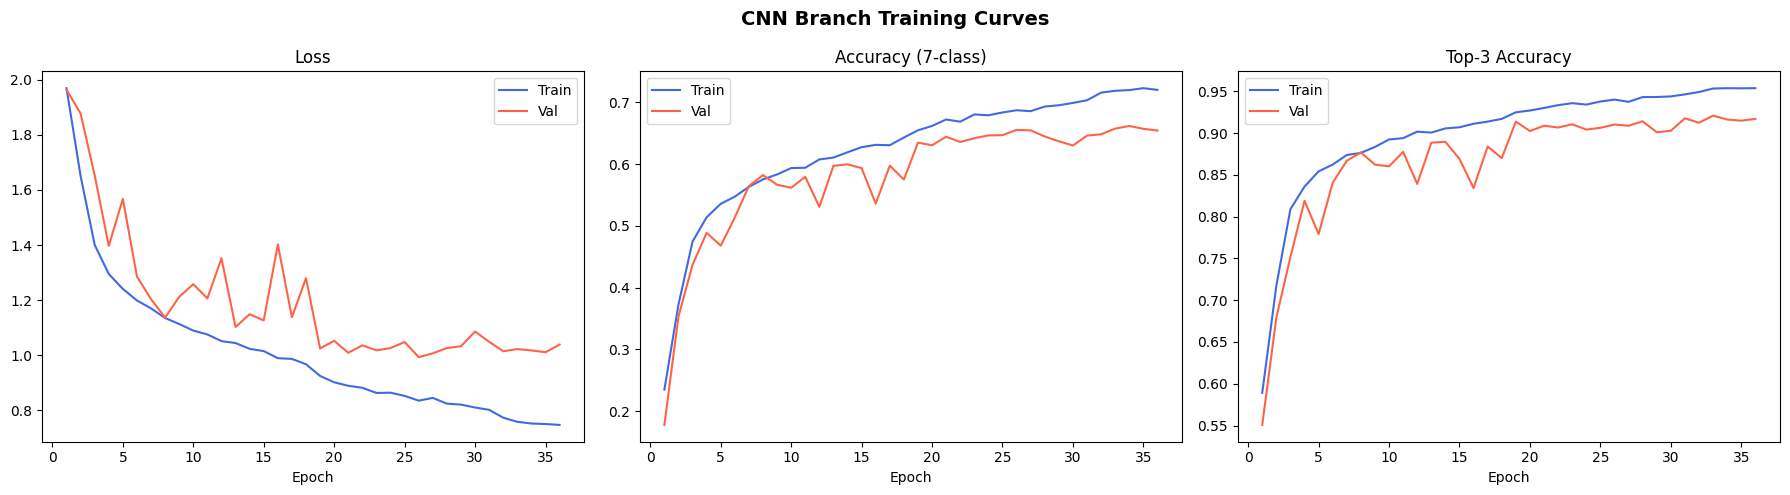

Saved → outputs/training_curves.png, training_history.json


In [18]:
# Cell 8 — Plot training curves
import json
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CNN Branch Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_ran, hist['loss'],     label='Train', color='royalblue')
axes[0].plot(epochs_ran, hist['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_ran, hist['accuracy'],     label='Train', color='royalblue')
axes[1].plot(epochs_ran, hist['val_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Accuracy (7-class)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

if 'top3_acc' in hist:
    axes[2].plot(epochs_ran, hist['top3_acc'],     label='Train', color='royalblue')
    axes[2].plot(epochs_ran, hist['val_top3_acc'], label='Val',   color='tomato')
    axes[2].set_title('Top-3 Accuracy'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'training_curves.png'), dpi=120)
plt.show()

# Save history
hist_serializable = {k: [float(v) for v in vals] for k, vals in hist.items()}
with open(OUTPUTS_DIR / 'training_history.json', 'w') as f:
    json.dump(hist_serializable, f, indent=2)
print('Saved → outputs/training_curves.png, training_history.json')